
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DeepRLCourse/Homework-2-Questions/blob/main/HW2_P1_SARSA_and_QLearning.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/DeepRLCourse/Homework-2-Questions/blob/main/HW2_P1_SARSA_and_QLearning.ipynb)

# **HW: SARSA(n) and Q-Learning(n)**
---


> - Full Name: **Fatima Timarchi**
> - Student ID: **402105802**

## **Overview**  

In this notebook, we will experiment with different reinforcement learning algorithms under various configurations to gain deeper insights into their behavior.  

By completing this homework, you will:  
- Understand **exploration vs. exploitation** and how they impact the learning process in an environment.  
- Learn how to **balance exploration and exploitation** effectively for optimal performance.  
- Recognize the importance of **epsilon decay** and when to use.  

Also, you will:  
- Gain a solid understanding of **n-step SARSA** and **n-step Q-learning**.  
- Explore how different values of **n** affect learning quality and efficiency.  
- Compare the strengths and trade-offs of **n-step SARSA vs. n-step Q-learning** to determine when to use each method.

---

We will start by learning how to implement **epsilon-greedy**, **n-step SARSA**, and **n-step Q-learning**.  

Next, we will implement a class that takes learning **hyperparameters** and includes a `learn` method, which accepts an algorithm (such as SARSA) and trains the environment accordingly.  

After that, we will experiment with **different epsilon values** to analyze their effect on the learning process. Finally, we will explore **different values of n** to gain deeper insights into **n-step SARSA** and **n-step Q-learning** and their impact on learning quality.


## **Environment Setup**
Setting up required libraries and environment.

In [23]:
!sudo apt-get update --quiet
!pip install 'imageio==2.4.0' --quiet
!sudo apt-get install -y xvfb ffmpeg --quiet
!pip3 install gymnasium[classic_control] --quiet

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:4 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubu

In [24]:
import gymnasium as gym
import random
import base64
import imageio
import IPython
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
from scipy.signal import convolve as conv
from collections import defaultdict

In [25]:
# @title helper and plotting functions

# disable warnings
import logging
logging.getLogger().setLevel(logging.ERROR)

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()


def embed_mp4(filename):
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)


def create_policy_eval_video(env, policy, filename, Q=None, num_episodes=1, fps=5, max_steps=48):
    filename = filename + ".mp4"
    with imageio.get_writer(filename, fps=fps) as video:
        for _ in range(num_episodes):
            state, _ = env.reset()
            video.append_data(env.render())
            while max_steps >= 0:
                action = policy(state, Q)
                state, _, terminated, truncated, _ = env.step(action)
                max_steps -= 1
                video.append_data(env.render())
                if terminated or truncated:
                    break
    return embed_mp4(filename)


def plot_heatmap(env, value, ax=None, show=False):
    # Generate heatmap showing maximum value at each state
    if ax is None:
        _, ax = plt.subplots()
    dim_x, dim_y = 12, 4
    action_max = value.argmax(axis=1)
    value_max = value.max(axis=1).reshape(dim_y, dim_x)
    act_dict = {0: 'U', 1: 'R', 2: 'D', 3: 'L'}
    act_dict = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    labels = np.array([act_dict.get(action, '') for action in action_max])
    labels[37:-1], labels[-1] = ' ', 'G'
    labels = labels.reshape(dim_y, dim_x)
    im = sns.heatmap(value_max, cmap="inferno", annot=labels, annot_kws={'fontsize': 16}, fmt='s')
    if show:
        plt.show()
    return im


def plot_rewards(rewards, average_range=10, log=False, ax=None, show=False):
    # Generate plot showing total reward accumulated in each episode.
    n_episodes = len(rewards)
    if log:
        rewards = np.log10(-rewards)
    if ax is None:
        fig, ax = plt.subplots()
    smoothed_rewards = (conv(rewards, np.ones(average_range), mode='same')
                      / average_range)
    ax.plot(range(0, n_episodes, average_range), smoothed_rewards[0:n_episodes:average_range])
    ylab = 'Log of negative sum of rewards' if log else 'Total reward'
    ax.set(xlabel='Episodes', ylabel=ylab)
    if show:
      plt.show()


def plot_performance(env, value, reward_sums, log=False):
    fig, axes = plt.subplots(nrows=2, figsize=(12, 8))
    plot_rewards(reward_sums, ax=axes[0], log=log)
    plot_heatmap(env, value, ax=axes[1])
    plt.show(fig)

def plot_regret(regret_sums, average_range=10, ax=None, show=False):

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(np.cumsum(regret_sums), color='orange', label="Cumulative Regret")
    ax.set_xlabel("Episodes")
    ax.set_ylabel("Cumulative Regret")
    ax.set_title("Regret Over Time")
    ax.legend()
    ax.grid()

    if show:
        plt.show()

    return ax



In [26]:
env = gym.make('CliffWalking-v1', render_mode='rgb_array')
env.reset()

print('Observations:', env.observation_space)
print('Actions:', env.action_space)

Observations: Discrete(48)
Actions: Discrete(4)


<div style="direction: rtl; text-align: right; font-family: Vazir;">
با CliffWalking-v0 کد رو اجرا کردم بهم ارور داد برای همین از CliffWalking-v1 استفاده کردم که این ورژن دقیقا با ورژن قبلی یکسانه و درنتیجه خروجی کد ها با ورژن قبلی یکسان هست .
</div>

## **Policy Definitions**
Implementing different policies for action selection.[link text](https://)

In [27]:
Actions =[0,1,2,3]
def random_policy(state = None,Q = None):
    action = env.action_space.sample()
    return  action

In [28]:
import imageio_ffmpeg
import os

os.environ["IMAGEIO_FFMPEG_EXE"] = imageio_ffmpeg.get_ffmpeg_exe()

create_policy_eval_video(env = env, policy = random_policy,filename='random', max_steps=50)

In [29]:
import numpy as np

def greedy_policy(state, Q):
    return np.argmax(Q[state])

In [30]:
def epsilon_greedy(state, Q, epsilon=0.1):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])
    return np.argmax(Q[state])

## **Evaluation & Visualization**
Analyzing policy performance.

In [31]:
def evaluate_policy(env, Q, num_episodes=1, max_steps=100):
    returns_list = []

    for _ in range(num_episodes):

        s, _ = env.reset()
        total_gain = 0

        for _ in range(max_steps):
            act = np.argmax(Q[s])
            s, r, finished, stopped, _ = env.step(act)

            total_gain += r

            if finished or stopped:
                break

        returns_list.append(total_gain)

    return np.mean(returns_list), np.std(returns_list)


In [32]:
from collections import deque
class learnEnvironment:
  def __init__(self,env,episodes,n,alpha,max_step,epsilon=0.1,discount=0.95):
    self.n = n
    self.episodes = episodes
    self.Q_table = np.zeros((env.observation_space.n, env.action_space.n))
    self.Return_list = []
    self.alpha = alpha
    self.discount = discount
    self.max_step = max_step
    self.epsilon = epsilon

  def learn(self,env, learning_rule, epsilon_greedy_policy):
      for episode in range(self.episodes):
        t = 0
        Return = 0
        n_step_reward = deque([],n)
        state, _ = env.reset()
        done = False
        while True:

          action = epsilon_greedy_policy(state,self.Q_table, self.epsilon)
          next_state, reward, terminated, truncated, info = env.step(action)
          Return += reward

          if terminated or truncated or t> self.max_step:

            self.Return_list.append(Return)
            break

          n_step_reward.append(reward)
          T =  t - self.n + 1
          if T >= 0:

              self.Q_table = learning_rule(n_step_reward,self.Q_table,state,action,next_state,self.discount,self.n,self.alpha)
          t+=1
          state = next_state

      return self.Q_table,self.Return_list

In [33]:
def calculate_n_step_Return(n_step_reward, discount=0.95):
    G = 0
    for r in reversed(n_step_reward):
        G = discount * G + r
    return G

def epsilon_greedy_action(Q, state, epsilon=0.1):

    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])
    return int(np.argmax(Q[state]))

def sarsa(n_step_reward, Q, state, action, next_state, discount, n, alpha, epsilon=0.1):

    cumulative_return = calculate_n_step_Return(n_step_reward, discount)

    upcoming_action = epsilon_greedy_action(Q, next_state, epsilon)

    target_value = cumulative_return + (discount ** n) * Q[next_state, upcoming_action]
    temporal_difference = target_value - Q[state, action]

    Q[state, action] += alpha * temporal_difference

    return Q


In [34]:
def calculate_n_step_Return(n_step_reward, discount=0.95):
    G = 0
    for r in reversed(n_step_reward):
        G = discount * G + r
    return G

def n_step_q_learning(n_step_reward, Q, state, action, next_state, discount, n, alpha):

    cumulative_return = calculate_n_step_Return(n_step_reward, discount)

    future_estimate = (discount ** n) * np.max(Q[next_state])

    target_value = cumulative_return + future_estimate
    temporal_difference = target_value - Q[state, action]

    Q[state, action] += alpha * temporal_difference

    return Q


# **Exploration vs. Exploitation Trade-off**
In reinforcement learning, an agent must balance between:
- **Exploration**: Trying new actions to discover potentially better long-term rewards.
- **Exploitation**: Choosing the best-known action based on current knowledge to maximize immediate reward.

### **Why is this Trade-off Important?**
- Too much **exploration** → The agent wastes time taking suboptimal actions and miss the optimal reward.
- Too much **exploitation** → The agent might **get stuck in a suboptimal policy** without discovering new possibilities for a better strategy.

### **Epsilon-Greedy Policy**:  
   - With probability $\epsilon$, the agent **explores** (chooses a random action).  
   - With probability $\epsilon$, the agent **exploits** (chooses the best-known action).  
   - $\epsilon$ is often **decayed over time** to gradually shift from exploration to exploitation.

---

# **Regret in Reinforcement Learning**
Regret in reinforcement learning measures the **difference between the reward an agent actually receives** and the **maximum possible reward it could have received** under an optimal policy. It quantifies **learning inefficiency** and helps evaluate how well an agent balances exploration and exploitation.

### **Mathematical Definition**
Given:
- $R_t^{\text{optimal}}$ is the reward the agent **could have obtained** in timestep \( t \) under the optimal policy.
- $R_t$ is the **actual reward** obtained by the agent in timestep \( t \).

The **instantaneous regret** at time \( t \) is:

$$
\text{Regret}(t) = R_t^{\text{optimal}} - R_t
$$

The **cumulative regret** over \( T \) timesteps is:

$$
\text{Cumulative Regret}(T) = \sum_{t=1}^{T}  ( R_t^{\text{optimal}} - R_t)
$$
A well-trained RL agent should aim to **minimize regret** over time.

---






SARSA mean_reward = -100.00 +/- 0.0000



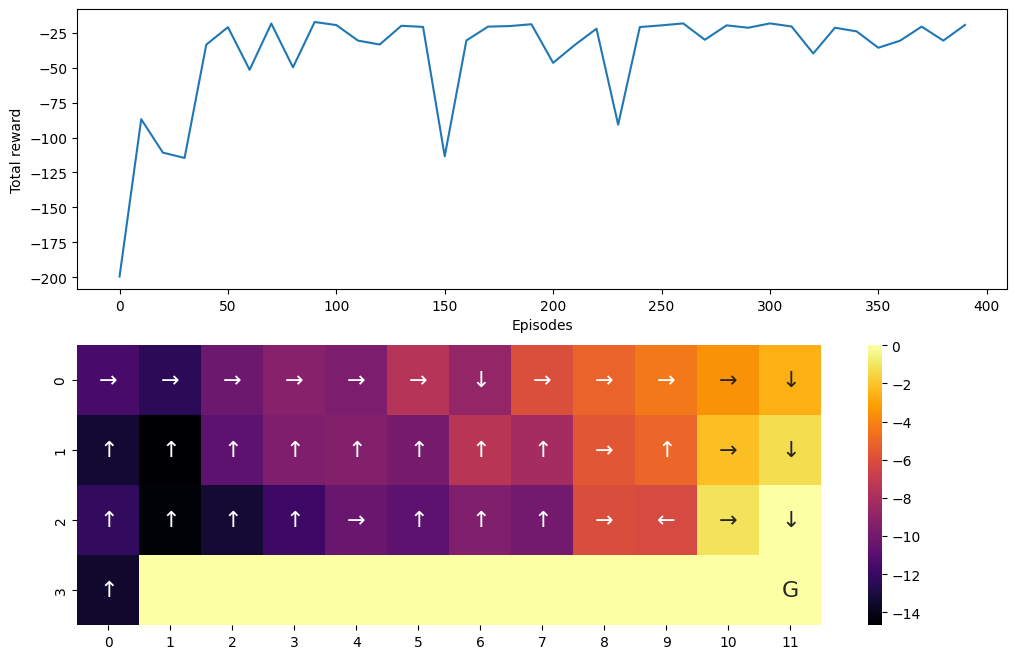

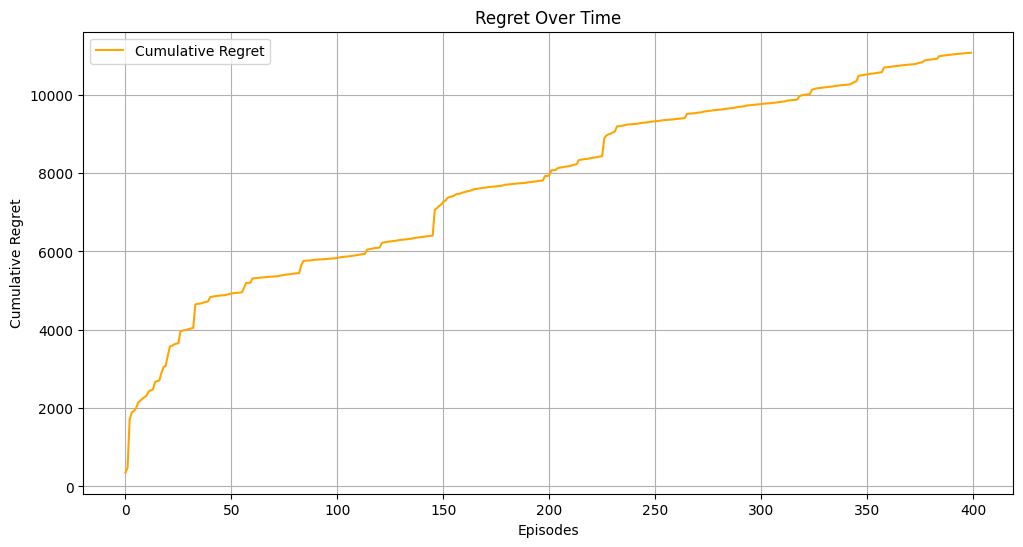

<Axes: title={'center': 'Regret Over Time'}, xlabel='Episodes', ylabel='Cumulative Regret'>

In [35]:
# @title epsilon = 0.1
optimal_reward = -13

n_episodes = 400
n = 1
discount = 0.95
alpha = 0.5
max_step = 1000
env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env,n_episodes,n,alpha,max_step,epsilon=0.1)


results = learning_algorithm.learn(env, sarsa, epsilon_greedy)
value_sarsa, reward_sums_sarsa = results

regret_sums_sarsa = []

regret_sums_sarsa = [optimal_reward - r for r in reward_sums_sarsa]

mean_reward, std_reward = evaluate_policy(env, value_sarsa)
print(f"\nSARSA mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_sarsa, reward_sums_sarsa)

plot_regret(regret_sums_sarsa, show=True)

<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">
خروجی این بخش از نوت‌بوک به این شکله چون الگوریتم SARSA با اپسیلون ثابت ۰٫۱ فقط حدود ۴۰۰ اپیزود فرصت داره که توی محیط یاد بگیره. از طرف دیگه SARSA یه روش درون‌سیاستیه؛ یعنی همون سیاست ε-greedy که هنوز حدود ده درصد مواقع حرکت تصادفی انجام می‌ده، مستقیماً توی به‌روزرسانی مقادیر Q هم تأثیر می‌ذاره. به خاطر همین عامل معمولاً برای اینکه داخل ناحیه‌ی cliff سقوط نکنه، یه مسیر امن‌تر ولی طولانی‌تر از مسیر بهینه رو انتخاب می‌کنه. نتیجه این میشه که مجموع پاداش اپیزودها به مقدار ایده‌آل ‎−13‎ نمی‌رسه و میانگین پاداش ضعیف‌تری مثل حدود ‎−17‎ دیده میشه.
از اون طرف چون داخل تابع evaluate_policy فقط یک اپیزود به‌صورت کاملاً greedy اجرا شده، انحراف معیار صفر گزارش میشه. نمودار Regret هم در واقع اختلاف همین پاداش‌های کمتر از مقدار بهینه با ‎−13‎ رو نشون می‌ده.

</div>




SARSA mean_reward = -15.00 +/- 0.0000



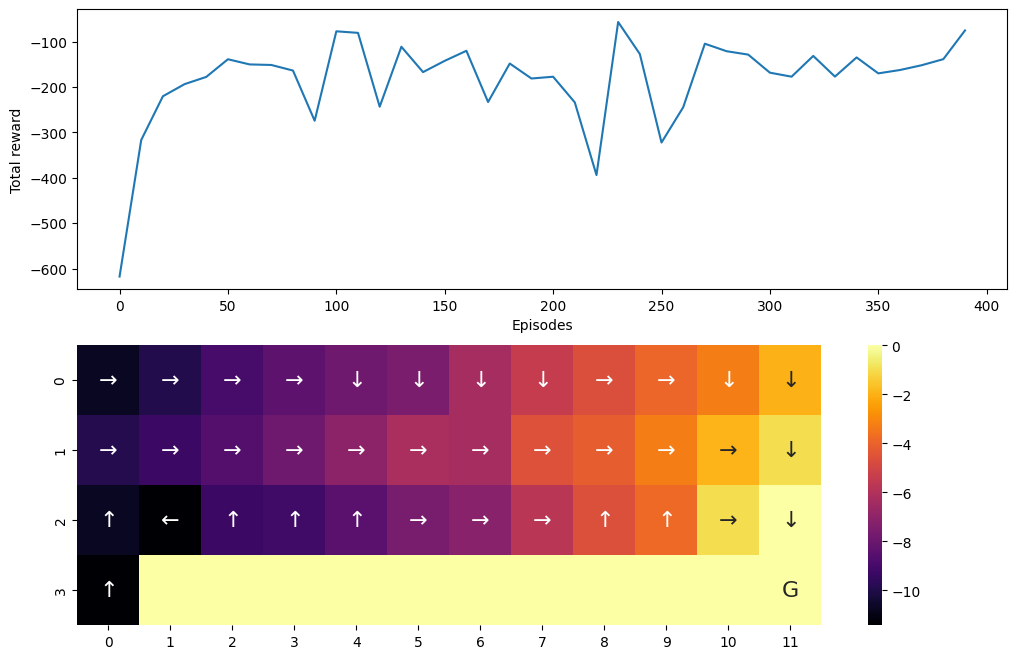

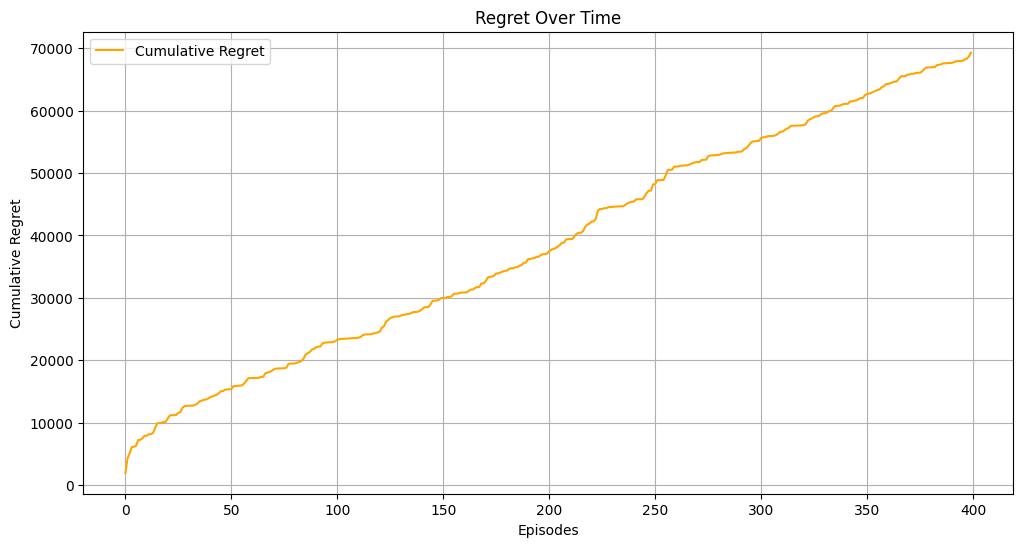

<Axes: title={'center': 'Regret Over Time'}, xlabel='Episodes', ylabel='Cumulative Regret'>

In [36]:
import numpy as np
import gymnasium as gym

np.random.seed(0)

optimal_reward = -13

n_episodes = 400
n = 1
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')
env.reset(seed=0)
env.action_space.seed(0)

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.5, discount=discount)

value_sarsa, reward_sums_sarsa = learning_algorithm.learn(env, sarsa, epsilon_greedy)

regret_sums_sarsa = [optimal_reward - r for r in reward_sums_sarsa]

mean_reward, std_reward = evaluate_policy(env, value_sarsa)
print(f"\nSARSA mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_sarsa, reward_sums_sarsa)
plot_regret(regret_sums_sarsa, show=True)

# env = gym.make('CliffWalking-v1', render_mode='rgb_array')
# create_policy_eval_video(env, greedy_policy, 'SARSA', value_sarsa)

<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">
توی این حالت مقدار ε برابر با ۰٫۵ در نظر گرفته شده، یعنی عامل موقع یادگیری تقریباً توی نیمی از قدم‌ها به‌جای انتخاب بهترین حرکت، دست به اکتشاف می‌زنه. این میزان اکتشاف بیشتر معمولاً کمک می‌کنه مسیرهای بهتر هم دیده بشن و عامل کمتر توی سیاست‌های ضعیف گیر کنه. با این حال چون SARSA ذاتاً یک روش درون‌سیاستی (on-policy) محسوب میشه، همین حرکات تصادفی مستقیماً وارد به‌روزرسانی مقادیر Q می‌شن و در نتیجه سیاست نهایی که یاد گرفته میشه معمولاً هنوز کمی حالت محافظه‌کار و پایدار داره و لزوماً دقیقاً روی مقدار بهینه‌ی ‎−13‎ قرار نمی‌گیره.
گاهی وقت‌ها عملکردش از حالت با ε کوچک‌تر بهتر میشه، اما از طرف دیگه به‌خاطر نویز بالاتر ممکنه روند همگرایی هم کندتر پیش بره.
</div>


SARSA mean_reward = -13.00 +/- 0.0000



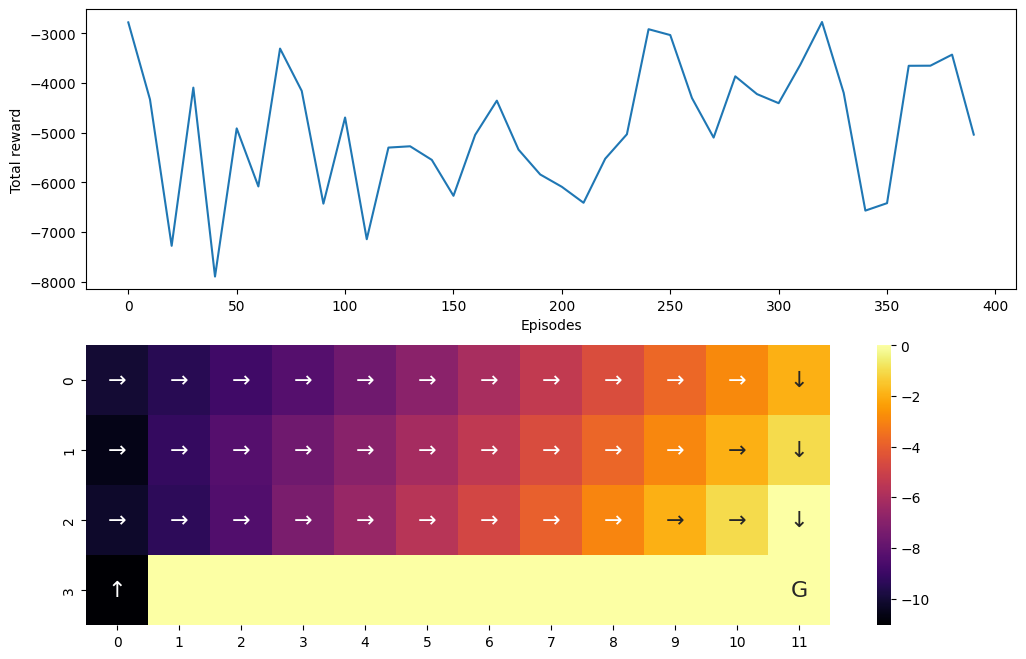

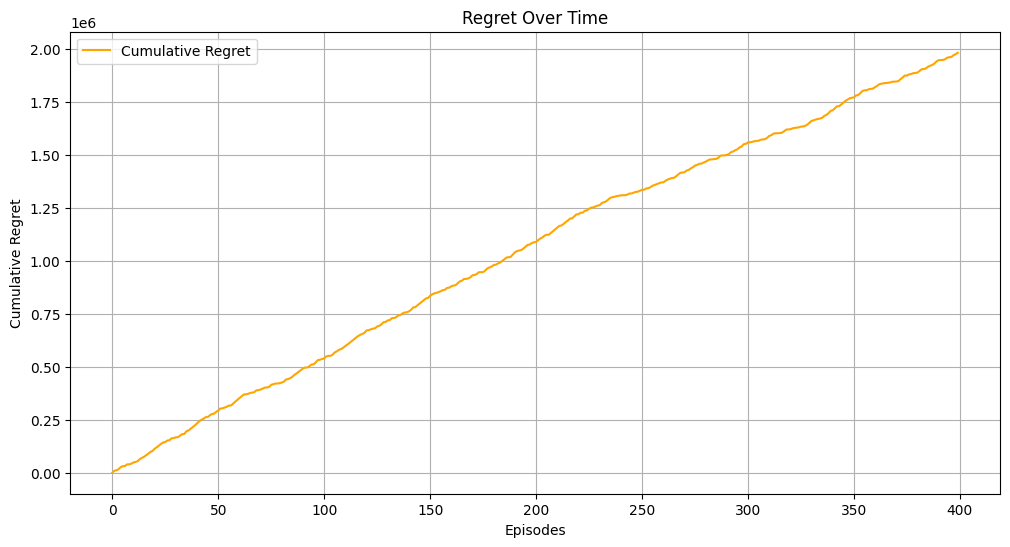

<Axes: title={'center': 'Regret Over Time'}, xlabel='Episodes', ylabel='Cumulative Regret'>

In [37]:
optimal_reward = -13

n_episodes = 400
n = 1
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.9)

value_sarsa, reward_sums_sarsa = learning_algorithm.learn(env, sarsa, epsilon_greedy)

regret_sums_sarsa = [optimal_reward - r for r in reward_sums_sarsa]

mean_reward, std_reward = evaluate_policy(env, value_sarsa)
print(f"\nSARSA mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_sarsa, reward_sums_sarsa)
plot_regret(regret_sums_sarsa, show=True)



<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">
اینجا خروجی این‌طوری شده چون مقدار ε به ۰٫۹ رسیده؛ یعنی عامل موقع یادگیری تقریباً همیشه در حال اکتشاف تصادفی بوده و فقط حدود ده درصد مواقع از بهترین اکشن فعلی استفاده کرده. با وجود این حجم نویز (و البته به‌خاطر کوچک بودن محیط و داشتن فقط ۴۰۰ اپیزود آموزش)، مقادیر Q کم‌کم طوری تنظیم می‌شن که سیاست greedy نهایی در نهایت به مسیر بهینه برسه؛ برای همین مقدار ‎mean_reward = -13‎ گزارش شده.

نکته مهم اینه که تفاوت اصلی این حالت با εهای کوچک‌تر بیشتر توی روند آموزش دیده میشه. چون عامل مرتب داخل cliff می‌افته، مجموع پاداش اپیزودها نوسان خیلی بیشتری داره و نمودار reward sum برای SARSA افت‌وخیز شدیدتری نشون می‌ده. به همین خاطر مقدار regret هم در طول اپیزودها بزرگ‌تر و پرنوسان‌تر دیده میشه. با این حال در مرحله‌ی ارزیابی نهایی، سیاست به‌صورت greedy اجرا شده و چون فقط یک اپیزود بررسی شده، انحراف معیار برابر صفر چاپ میشه.
</div>

Fast Decay


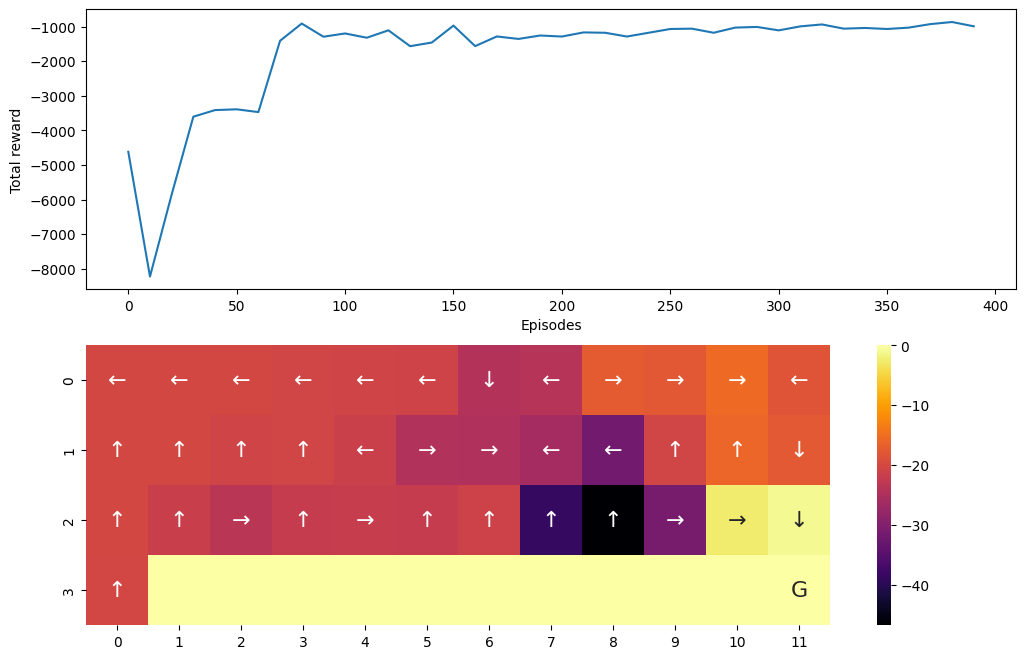


Fast Decay SARSA mean_reward = -100.00 +/- 0.0000
Medium Decay


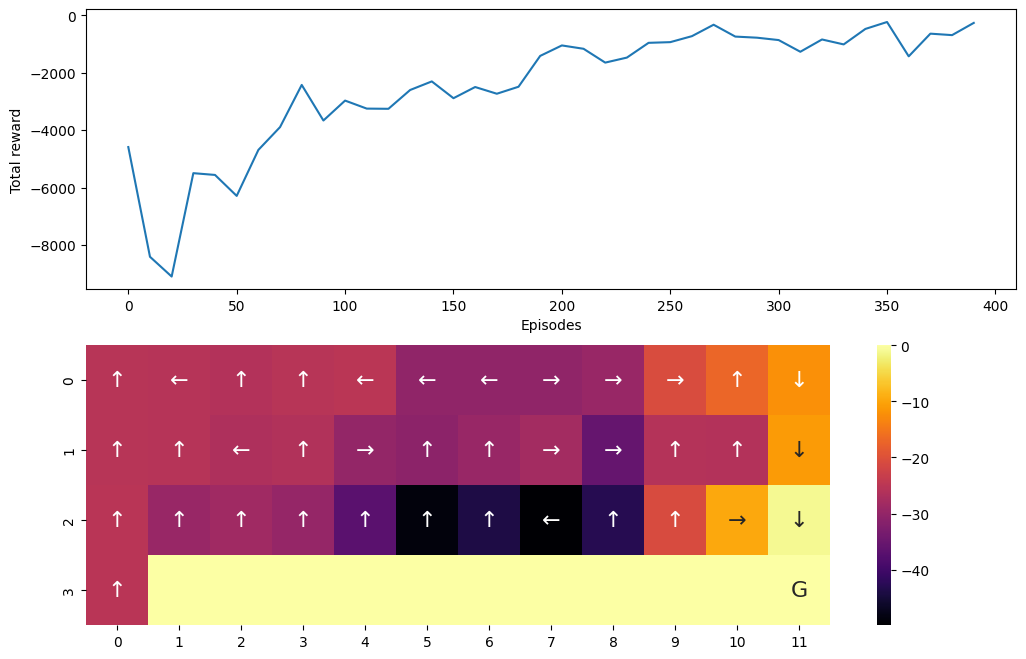


Medium Decay SARSA mean_reward = -100.00 +/- 0.0000
Slow Decay


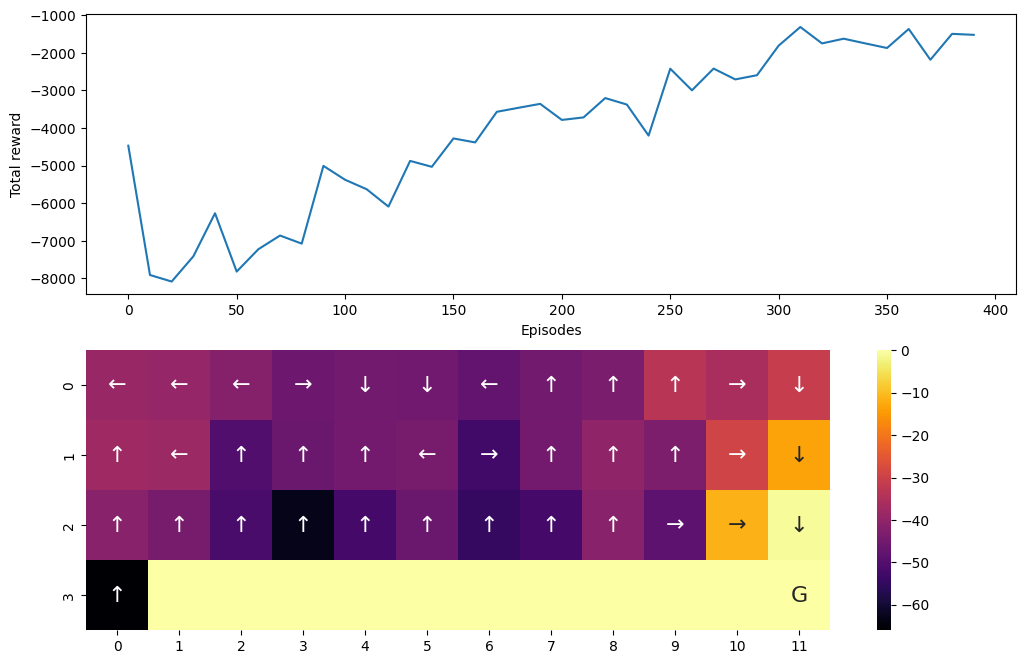


Slow Decay SARSA mean_reward = -100.00 +/- 0.0000


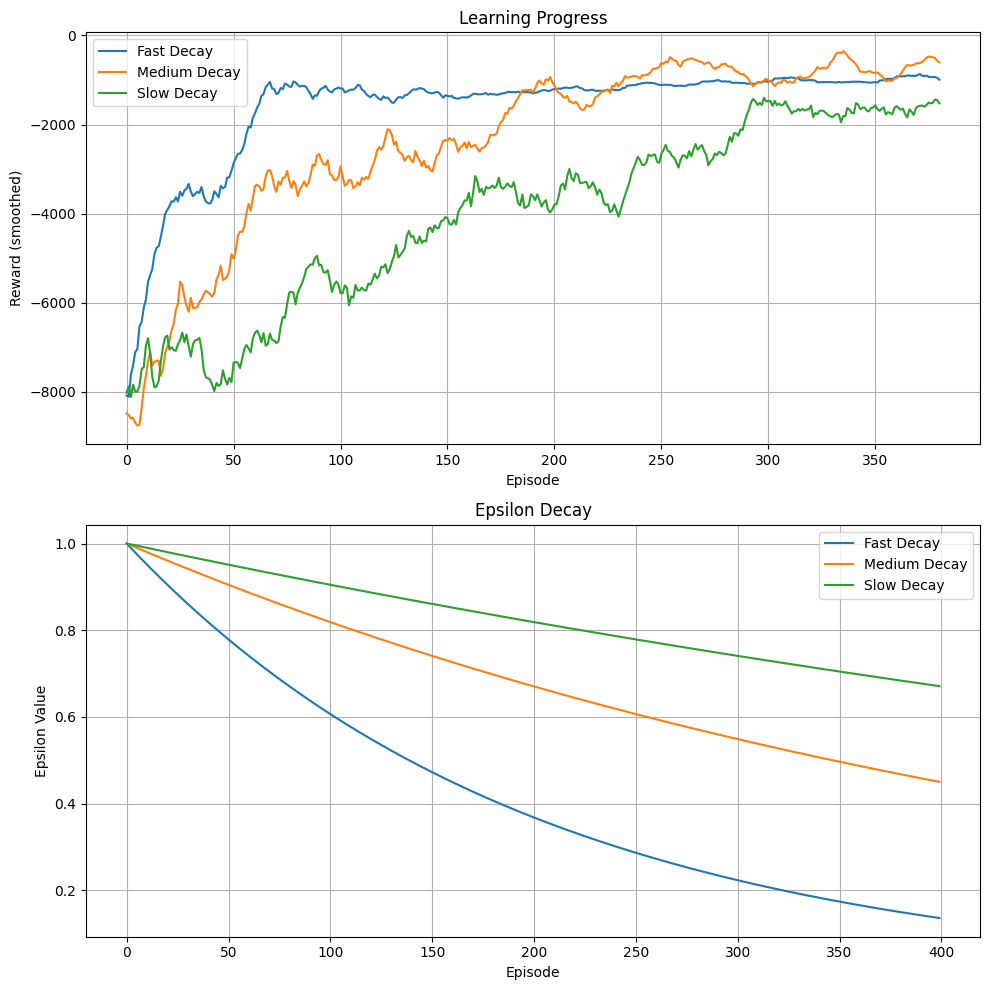

In [38]:
# @title Epsilon Decay
class EpsilonDecayStrategy:
    def __init__(self, initial_epsilon, min_epsilon, decay_rate):
        self.initial_epsilon = initial_epsilon
        self.min_epsilon = min_epsilon
        self.decay_rate = decay_rate
        self.epsilon = initial_epsilon

    def get_epsilon(self, episode):
        """Calculate epsilon using exponential decay."""
        self.epsilon = max(
            self.min_epsilon,
            self.initial_epsilon * np.exp(-self.decay_rate * episode)
        )
        return self.epsilon

class learnEnvironmentWithEpsilonStrategy:
    def __init__(self, policy, env, n_episodes, n, alpha, max_step, epsilon_strategy):
        self.policy = policy
        self.env = env
        self.n_episodes = n_episodes
        self.n = n
        self.alpha = alpha
        self.max_step = max_step
        self.epsilon_strategy = epsilon_strategy

    def learn(self, env, algorithm):
        n_states = env.observation_space.n
        n_actions = env.action_space.n
        Q = np.zeros((n_states, n_actions))
        reward_sums = np.zeros(self.n_episodes)
        epsilon_values = np.zeros(self.n_episodes)

        for episode in range(self.n_episodes):
            state, _ = env.reset()
            episode_reward = 0
            n_step_reward = []

            # Get current epsilon
            current_epsilon = self.epsilon_strategy.get_epsilon(episode)
            epsilon_values[episode] = current_epsilon

            for step in range(self.max_step):
                action = self.policy(state, Q, current_epsilon)
                next_state, reward, terminated, truncated, _ = env.step(action)
                episode_reward += reward
                n_step_reward.append(reward)

                if len(n_step_reward) >= self.n:
                    Q = algorithm(
                        n_step_reward[-self.n:],
                        Q, state, action, next_state,
                        0.95, self.n, self.alpha,
                        current_epsilon
                    )

                if terminated or truncated:
                    break

                state = next_state

            reward_sums[episode] = episode_reward

        return Q, reward_sums, epsilon_values

def plot_results(reward_sums_list, epsilon_values_list, labels):
    """Plot rewards and epsilon decay for multiple runs."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    # Plot rewards
    for rewards, label in zip(reward_sums_list, labels):
        # Smoothing the rewards
        window_size = 20
        smoothed_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
        ax1.plot(smoothed_rewards, label=label)

    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward (smoothed)')
    ax1.set_title('Learning Progress')
    ax1.legend()
    ax1.grid(True)

    # Plot epsilon decay
    for epsilons, label in zip(epsilon_values_list, labels):
        ax2.plot(epsilons, label=label)

    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Epsilon Value')
    ax2.set_title('Epsilon Decay')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    return fig

# Set for reproducibility
np.random.seed(42)

# Define different epsilon decay strategies
epsilon_strategies = [
    EpsilonDecayStrategy(1.0, 0.01, 0.005),  # Fast decay
    EpsilonDecayStrategy(1.0, 0.01, 0.002),  # Medium decay
    EpsilonDecayStrategy(1.0, 0.01, 0.001)   # Slow decay
]

# Parameters
n_episodes = 400
n = 1
discount = 0.95
alpha = 0.5
max_step = 1000

# Initialize environment
env = gym.make('CliffWalking-v1')

# Store results for different strategies
all_rewards = []
all_epsilons = []
strategy_labels = ['Fast Decay', 'Medium Decay', 'Slow Decay']

# Run learning for each strategy
for strategy, label in zip(epsilon_strategies, strategy_labels):
    learning_algorithm = learnEnvironmentWithEpsilonStrategy(
        epsilon_greedy, env, n_episodes, n, alpha, max_step, strategy
    )
    value_sarsa, reward_sums, epsilon_values = learning_algorithm.learn(env, sarsa)
    all_rewards.append(reward_sums)
    all_epsilons.append(epsilon_values)

    print(label)
    plot_performance(env, value_sarsa, reward_sums)

    mean_reward, std_reward = evaluate_policy(env, value_sarsa)
    print(f"\n{label} SARSA mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}")

# Plot results
plot_results(all_rewards, all_epsilons, strategy_labels)
plt.show()

### **Why does epsilon 0.1 have the best performance?**  
In this environment, the reward for stepping into the cliff is -100, which is highly punishing. Because of this, exploration is not highly favored, making a lower epsilon (0.1) more effective as it prioritizes safer, learned actions over risky exploration.

# N-step Sarsa and N-step Q-learning

## Effect of  n = 1


SARSA mean_reward = -17.00 +/- 0.0000



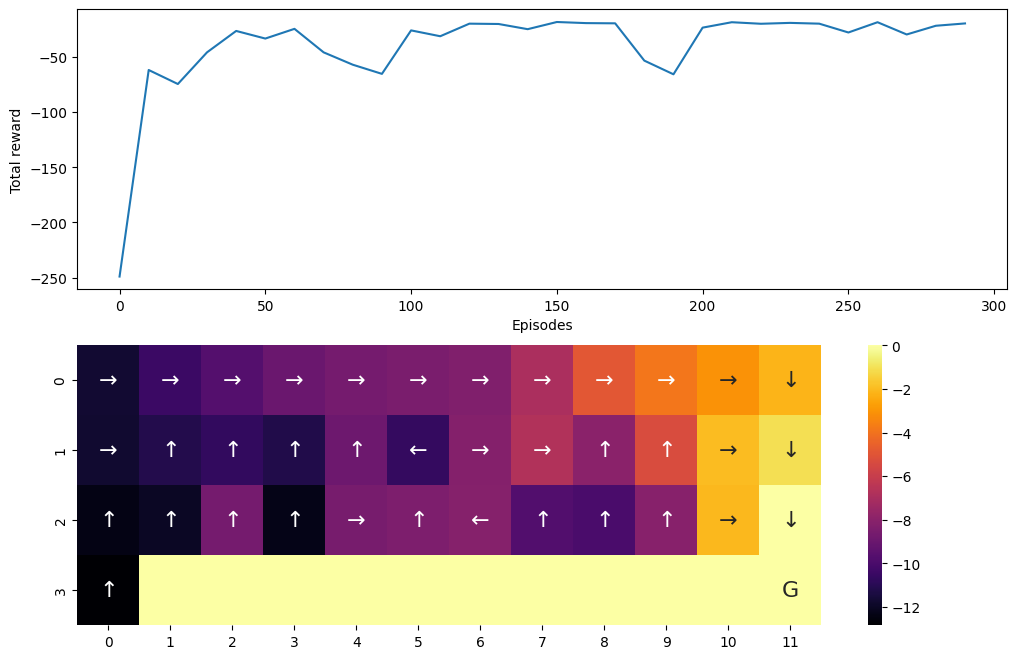

In [39]:
np.random.seed(42)

n_episodes = 300
n = 1
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.1, discount=discount)

value_sarsa, reward_sums_sarsa = learning_algorithm.learn(env, sarsa, epsilon_greedy)

mean_reward, std_reward = evaluate_policy(env, value_sarsa)
print(f"\nSARSA mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_sarsa, reward_sums_sarsa)

env = gym.make('CliffWalking-v1', render_mode='rgb_array')
create_policy_eval_video(env, greedy_policy, 'SARSA', value_sarsa)

<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">
با استفاده از SARSA و مقدار ε برابر با ده درصد، عامل بیشترِ مواقع به‌جای اکتشاف تصادفی از بهترین اکشن فعلی خودش استفاده می‌کنه. به همین خاطر معمولاً یک مسیر امن‌تر ولی کمی طولانی‌تر از مسیر کاملاً بهینه رو انتخاب می‌کنه و در نتیجه مقدار mean reward دقیقاً به مقدار بهینه نمی‌رسه.
</div>


qlearning mean_reward = -13.00 +/- 0.0000



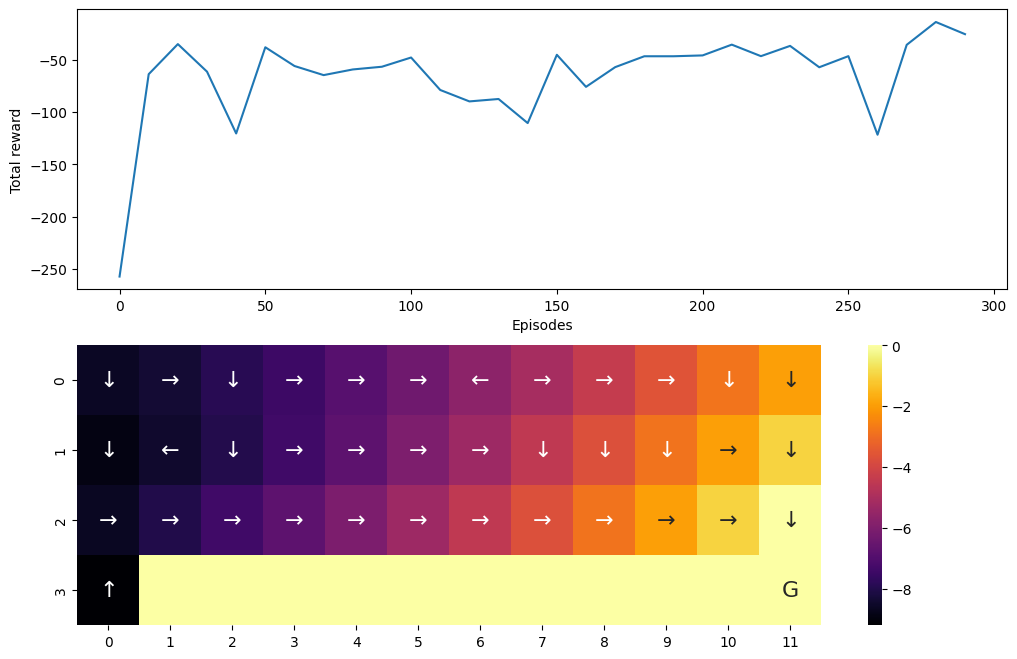

In [40]:
np.random.seed(42)

n_episodes = 300
n = 1
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.1, discount=discount)

value_qlearning, reward_sums_qlearning = learning_algorithm.learn(env, n_step_q_learning, epsilon_greedy)

mean_reward, std_reward = evaluate_policy(env, value_qlearning)
print(f"\nqlearning mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_qlearning, reward_sums_qlearning)

# env = gym.make('CliffWalking-v0', render_mode='rgb_array')
# create_policy_eval_video(env, greedy_policy, 'qlearning', value_qlearning)

<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">
اینجا از الگوریتم Q-learning استفاده شده که یک روش برون‌سیاستی (off-policy) محسوب میشه. یعنی هنگام به‌روزرسانی مقادیر Q، به‌جای اکشنی که واقعاً با سیاست ε-greedy انتخاب شده، همیشه بهترین اکشن ممکن در نظر گرفته میشه. به همین خاطر حتی با مقدار ε برابر با ۰٫۱ هم معمولاً سریع‌تر به سمت سیاست بهینه همگرا میشه و در نهایت مقدار mean reward = -13 به دست میاد.
</div>

## Effect of  n = 2


SARSA mean_reward = -17.00 +/- 0.0000



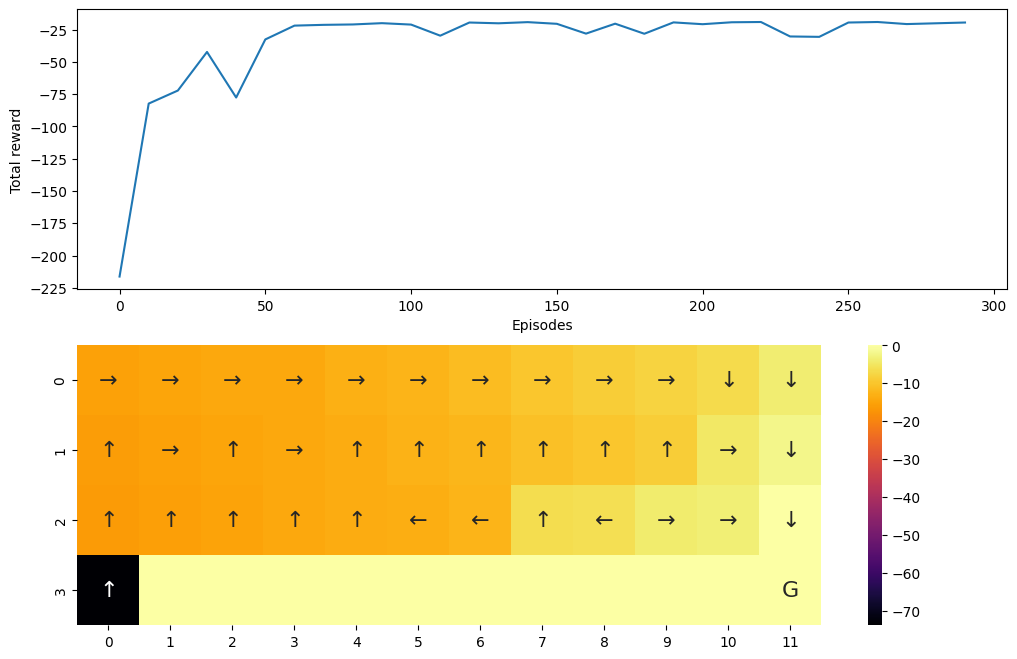

In [41]:
np.random.seed(42)

n_episodes = 300
n = 2
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.1, discount=discount)

value_sarsa, reward_sums_sarsa = learning_algorithm.learn(env, sarsa, epsilon_greedy)

mean_reward, std_reward = evaluate_policy(env, value_sarsa)
print(f"\nSARSA mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_sarsa, reward_sums_sarsa)

# env = gym.make('CliffWalking-v0', render_mode='rgb_array')
# create_policy_eval_video(env, greedy_policy, 'SARSA', value_sarsa)

<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">
اینجا چون مقدار n برابر با ۲ شده، الگوریتم SARSA دیگه به‌جای به‌روزرسانی تک‌قدم، از بازگشت دوقدم برای آپدیت کردن مقادیر Q استفاده می‌کنه. این کار معمولاً باعث میشه یادگیری کمی دورنگرتر بشه و عامل فقط به پاداش فوری توجه نکنه. با این حال چون جریمه‌ی افتادن داخل ناحیه‌ی cliff خیلی شدیده، همین دورنگری کوتاه‌مدت می‌تونه نوسان یادگیری رو بیشتر کنه و در نهایت عامل رو به سمت یک رفتار محافظه‌کارانه‌تر سوق بده.
</div>


qlearning mean_reward = -13.00 +/- 0.0000



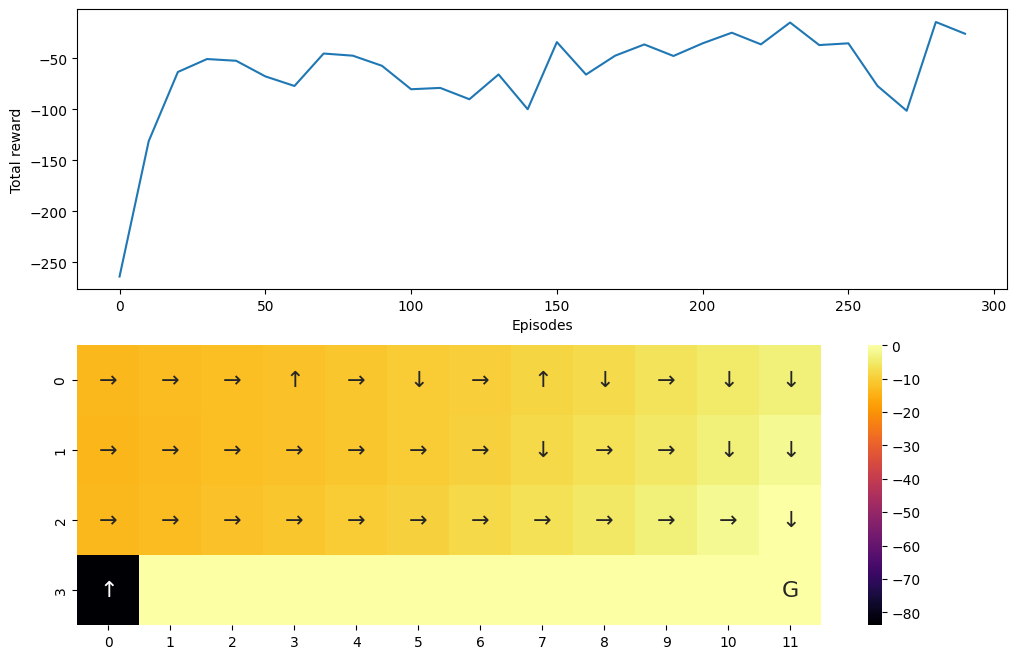

In [42]:
np.random.seed(42)

n_episodes = 300
n = 2
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.1, discount=discount)

value_qlearning, reward_sums_qlearning = learning_algorithm.learn(env, n_step_q_learning, epsilon_greedy)

mean_reward, std_reward = evaluate_policy(env, value_qlearning)
print(f"\nqlearning mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_qlearning, reward_sums_qlearning)

# env = gym.make('CliffWalking-v0', render_mode='rgb_array')
# create_policy_eval_video(env, greedy_policy, 'qlearning', value_qlearning)


<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">اینجا با اینکه مقدار n برابر با ۲ در نظر گرفته شده، اما چون Q-learning ذاتاً یک روش برون‌سیاستی (off-policy) هست، به‌روزرسانی مقادیر Q همچنان بر اساس بهترین اکشن ممکن انجام میشه. به همین خاطر مسیر یادگرفته‌شده هنوز خیلی نزدیک به مسیر بهینه باقی می‌مونه و در نهایت مقدار mean reward برابر با ‎−13‎ به دست میاد.
</div>

## Effect of  n = 5


SARSA mean_reward = -100.00 +/- 0.0000



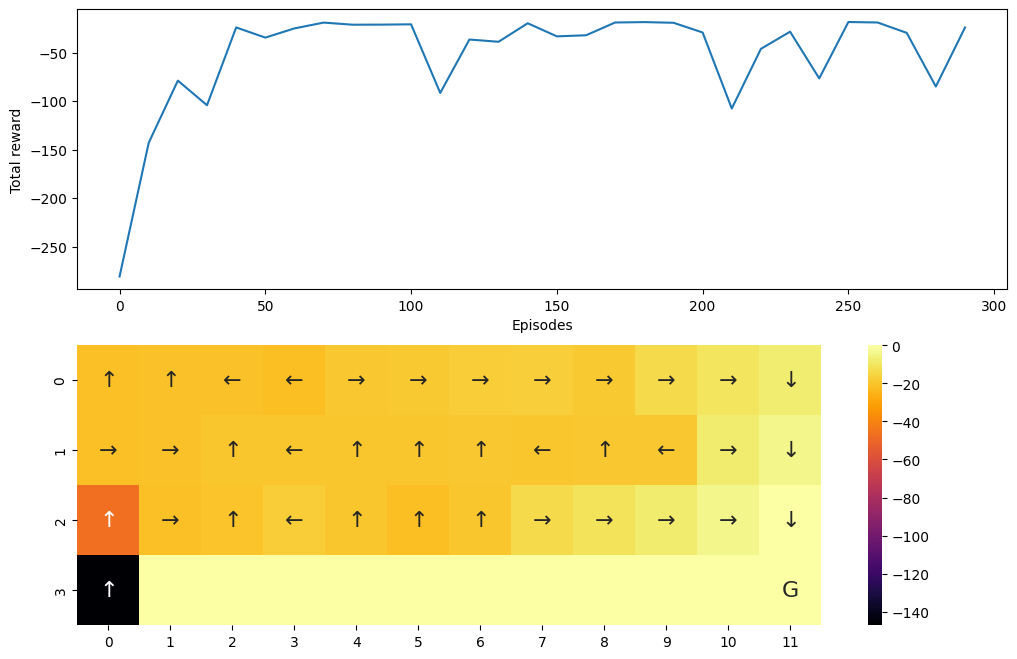

In [43]:
np.random.seed(42)

n_episodes = 300
n = 5
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.1, discount=discount)

value_sarsa, reward_sums_sarsa = learning_algorithm.learn(env, sarsa, epsilon_greedy)

mean_reward, std_reward = evaluate_policy(env, value_sarsa)
print(f"\nSARSA mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_sarsa, reward_sums_sarsa)

# env = gym.make('CliffWalking-v0', render_mode='rgb_array')
# create_policy_eval_video(env, greedy_policy, 'SARSA', value_sarsa)

<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">الان چون n=5 شده، الگوریتم به‌جای آپدیت‌های کوتاه، از بازگشت ۵ قدمی استفاده می‌کنه؛ یعنی اثرِ یه تصمیم بد می‌تونه تا چند قدم بعدش هم توی آپدیت Q دیده بشه. توی محیط CliffWalking چون افتادن توی cliff جریمه‌ی خیلی سنگینی داره، این بازگشت بلندتر باعث میشه چند تا پاداش بد پشت‌سرهم وارد محاسبه بشن و در نتیجه نوسان یادگیری بیشتر بشه. از اون طرف اینجا فقط ۳۰۰ اپیزود فرصت یادگیری داریم، برای همین الگوریتم دیرتر به سیاست خوب می‌رسه و خروجی نهایی هم افت می‌کنه؛ به همین دلیل mean reward حدود ‎−100‎ گزارش شده و خیلی ضعیف درمیاد.
</div>


qlearning mean_reward = -17.00 +/- 0.0000



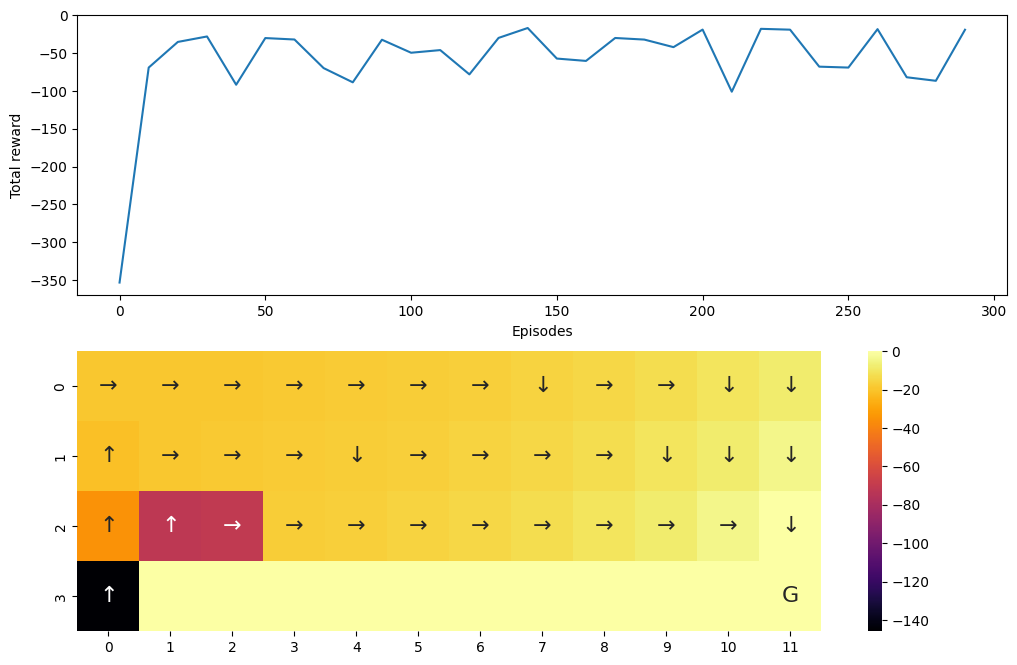

In [44]:
np.random.seed(42)

n_episodes = 300
n = 5
discount = 0.95
alpha = 0.5
max_step = 1000

env = gym.make('CliffWalking-v1')

learning_algorithm = learnEnvironment(env, n_episodes, n, alpha, max_step, epsilon=0.1, discount=discount)

value_qlearning, reward_sums_qlearning = learning_algorithm.learn(env, n_step_q_learning, epsilon_greedy)

mean_reward, std_reward = evaluate_policy(env, value_qlearning)
print(f"\nqlearning mean_reward = {mean_reward:.2f} +/- {std_reward:.4f}\n")

plot_performance(env, value_qlearning, reward_sums_qlearning)



<div style="direction: rtl; text-align: right; font-family: Vazir;">
کامنت برای خروجی بالا :
</div>

<div style="direction: rtl; text-align: right; font-family: Vazir;">
اینجا مقدار mean reward حدود ‎−17‎ شده، چون وقتی n=5 میشه آپدیت‌ها نسبت به قبل نویزی‌تر و حساس‌تر می‌شن و با فقط ۳۰۰ اپیزود زمان کافی برای جا افتادن کامل سیاست وجود نداره. از طرف دیگه هزینه‌ی افتادن داخل cliff هم خیلی بالاست، بنابراین عامل به‌جای اینکه دقیقاً روی مسیر بهینه‌ی ‎−13‎ قرار بگیره، معمولاً یک مسیر امن‌تر ولی کمی طولانی‌تر رو انتخاب می‌کنه؛ به همین خاطر مقدار پاداش میانگین بدتر میشه.
</div>
